# Soc5044 Computational Sociology W9 Practicum - K-means and Hierarchical Clustering

These teaching materials are adpated from the official website of [*Scikit Learn*](https://scikit-learn.org/stable/index.html) for the course "Soc5044 Computational Sociology" lectured at the sociology department of National Taiwan University by Dr. Chen-Shuo Hong.

In particular, this file uses the following web pages:
- "2.3 Clustering", Section 2 Unsupervised Learning.
    - [2.3.2 K-means](https://scikit-learn.org/stable/modules/clustering.html#k-means)
    - [2.3.6 Hierarchical clustering](https://scikit-learn.org/stable/modules/clustering.html#hierarchical-clustering)

Editor: Jun-Wei Liu (b09902009@ntu.edu.tw)

---

# Introduction to Clustering

Clustering is a type of unsupervised machine learning technique used to group similar data points together based on their features. Unlike supervised learning, clustering does not require labeled data. Instead, it identifies inherent structures in the data by grouping data points that are more similar to each other than to those in other groups.

In social research, clustering can be particularly useful for identifying patterns and segmenting populations based on their responses to various questions. For example, researchers can use clustering to:
- Group individuals with similar socio-economic backgrounds.
- Identify communities with similar social behaviors.
- Analyze social networks by detecting communities within the network.

# K-means

The K-means algorithm clusters data by trying to separate samples in n groups of equal variance. This algorithm requires the number of clusters to be specified. It scales well to large numbers of samples and has been used across a large range of application areas in many different fields.

The k-means algorithm divides a set of $N$ samples into $K$ disjoint clusters $C$, each described by the mean $\mu_j$ of the samples in the cluster.
The means are commonly called the cluster "centroids"; note that they are not, in general, points from $X$, although they live in the same space.

The K-means algorithm aims to choose centroids that minimise the **inertia**, or **within-cluster sum-of-squares criterion**:

```math
\sum_{i=0}^{n}\min_{\mu_j \in C}(||x_i - \mu_j||^2)
```

Inertia can be recognized as a measure of how internally coherent clusters are. It suffers from various drawbacks:

- Inertia makes the assumption that clusters are convex and isotropic, which is not always the case. It responds poorly to elongated clusters, or manifolds with irregular shapes.

- Inertia is not a normalized metric: we just know that lower values are better and zero is optimal. But in very high-dimensional spaces, Euclidean distances tend to become inflated (this is an instance of the so-called “curse of dimensionality”). Running a dimensionality reduction algorithm such as Principal component analysis (PCA) prior to k-means clustering can alleviate this problem and speed up the computations.

![unexpected-k-means](../images/w8-clustering-unexpected-outcomes-of-k-means.png)

> "2.3.2 K-means", Section 2 Clustering. Scikit Learn. https://scikit-learn.org/stable/modules/clustering.html#k-means

## Algorithm

K-means is often referred to as Lloyd’s algorithm. In basic terms, the algorithm has three steps:

1. Chooses the initial centroids, with the most basic method being to choose samples from the dataset. After initialization, K-means consists of looping between the two other steps.
1. The first step assigns each sample to its nearest centroid.
1. The second step creates new centroids by taking the mean value of all of the samples assigned to each previous centroid.

The difference between the old and the new centroids are computed and the algorithm repeats these last two steps until this value is less than a threshold. In other words, it repeats until the centroids do not move significantly.


Belows is an example of the convergence of k-means algorithm over iterations.

![k-means-convergence](../images/Clustering-K-means-convergence.gif)
> David Sheehan (2017). Clustering with Scikit with GIFs. https://dashee87.github.io/data%20science/general/Clustering-with-Scikit-with-GIFs/

# Hierarchical clustering

Hierarchical clustering is a general family of clustering algorithms that build nested clusters by merging or splitting them successively. This hierarchy of clusters is represented as a tree (or dendrogram). The root of the tree is the unique cluster that gathers all the samples, the leaves being the clusters with only one sample.

![hierarchical-clustering-tree](../images/Clustering-hierarchical-tree.png)

> "2.3.6 Hierarchical Clustering", Section 2 Clustering. Scikit Learn. https://scikit-learn.org/stable/modules/clustering.html#hierarchical-clustering


## Algorithm

In Scikit Learn, the `AgglomerativeClustering` object performs a hierarchical clustering using a bottom up "merging" approach: each observation starts in its own cluster, and clusters are successively merged together.

The linkage criteria determines the metric used for the merge strategy:

- **Ward** minimizes the sum of squared differences within all clusters. It is a variance-minimizing approach and in this sense is similar to the k-means objective function but tackled with an agglomerative hierarchical approach.

- **Maximum or complete linkage** minimizes the maximum distance between observations of pairs of clusters.

- **Average linkage** minimizes the average of the distances between all observations of pairs of clusters.

- **Single linkage** minimizes the distance between the closest observations of pairs of clusters.

Below show the difference outcomes between linkage types.

![hierarchical-clustering-linkage-types](../images/Clustering-hierarchical-linkage-types.png)

> "2.3.6 Hierarchical Clustering", Section 2 Clustering. Scikit Learn. https://scikit-learn.org/stable/modules/clustering.html#hierarchical-clustering

## Example with Taiwan Youth Project (TYP) dataset

Clustering can help us identify groups of individuals who exhibit similar social behaviors and then explore the unique characteristics of each subgroup.

Let's say, we want to answer the question: '*What are the distinct patterns of parent-child interaction, and how do these patterns relate to satisfaction with family relationships?*'

Let's again use the dataset [台灣青少年成長歷程研究：TYP2017調查(成人合併樣本第三波)](https://srda.sinica.edu.tw/search/metadata/detail/D00188).
- Target population: "2000年為台北市、台北縣以及宜蘭縣的國中學生".
- Survey period: 2017/9 to 2018/3.
- Sample size: 2551.

> 伊慶春（2021）。台灣青少年成長歷程研究：TYP2017調查(成人合併樣本第三波)（公共版）（D00188）【原始數據】取自中央研究院人文社會科學研究中心調查研究專題中心學術調查研究資料庫。https://doi.org/10.6141/TW-SRDA-D00188-1

In [45]:
import pandas as pd

# Load CSV file
file_path = "../data/typ2017-adult-wave3/TYP2017_Jan2021.csv"
df = pd.read_csv(file_path, encoding="big5", low_memory=False)

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2551 entries, 0 to 2550
Columns: 976 entries, m3sschool to m3ssu6003
dtypes: int64(905), object(71)
memory usage: 19.0+ MB
None


We use the following variables to capture the different aspects of parent-child interaction.

- Interaction frequency - q12: 這一年來，你與父母的聯絡情形如何？(自己父親與自己母親)
    - `m3s01201c`, `m3s01202c`: 這一年來，見面多少次？
    - `m3s01201d`, `m3s01202d`: 這一年來，除了見面之外，多久聯絡一次?（電話、skype、line、電子郵件）
    - `m3s01201e`, `m3s01202e`: 這一年來，你平常多久跟父母一起吃飯？
- Support - q14: 過去一年來，你自己父母常不常提供給你以下的幫助？(自己父親與自己母親)
    - `m3s01401a`, `m3s01402a`: 給我錢
    - `m3s01401b`, `m3s01402b`: 幫我料理家務(例如打掃、準備晚餐、買東西、代辦雜事)或照顧小孩或其他家人
    - `m3s01401c`, `m3s01402c`: 聽我的心事或想法
    - `m3s01401d`, `m3s01402d`: 在我的工作上提供協助
- Conflict - q16: 家人相處難免會有衝突，我們想請問你家人之間相處的情形。(與父母之間)
    - `m3s016010`: 過去一年裡，你家是否發生過下列狀況？你與父母之間：(1)不理人（冷戰）
    - `m3s016020`: 過去一年裡，你家是否發生過下列狀況？你與父母之間：(2)吵嘴
    - `m3s016030`: 過去一年裡，你家是否發生過下列狀況？你與父母之間：(3)丟東西或打架（打人）
    - `m3s016040`: 過去一年裡，你家是否發生過下列狀況？你與父母之間：(4)用非常難聽的話罵人
    - `m3s016050`: 過去一年裡，你家是否發生過下列狀況？你與父母之間：(5)有一方會讓人緊張、害怕

We're averaging the variables within each category to get a single, continuous value.

In [46]:
# Interaction frequency
df['interaction_frequency_c'] = df[['m3s01201c', 'm3s01202c']].replace({0: pd.NA, 97: pd.NA, 98: pd.NA, 99: pd.NA}).apply(lambda x: 7-x).mean(axis=1, skipna=True)
df['interaction_frequency_d'] = df[['m3s01201d', 'm3s01202d']].replace({0: pd.NA, 97: pd.NA, 98: pd.NA, 99: pd.NA}).apply(lambda x: 7-x).mean(axis=1, skipna=True)
df['interaction_frequency_e'] = df[['m3s01201e', 'm3s01202e']].replace({0: pd.NA, 97: pd.NA, 98: pd.NA, 99: pd.NA}).apply(lambda x: 7-x).mean(axis=1, skipna=True)
df['interaction_frequency'] = df[['interaction_frequency_c', 'interaction_frequency_d', 'interaction_frequency_e']].mean(axis=1, skipna=True)

# Support
df['support_a'] = df[['m3s01401a', 'm3s01402a']].replace({0: pd.NA, 7: pd.NA, 8: pd.NA, 9: pd.NA}).apply(lambda x: 5-x).mean(axis=1, skipna=True)
df['support_b'] = df[['m3s01401b', 'm3s01402b']].replace({0: pd.NA, 7: pd.NA, 8: pd.NA, 9: pd.NA}).apply(lambda x: 5-x).mean(axis=1, skipna=True)
df['support_c'] = df[['m3s01401c', 'm3s01402c']].replace({0: pd.NA, 7: pd.NA, 8: pd.NA, 9: pd.NA}).apply(lambda x: 5-x).mean(axis=1, skipna=True)
df['support_d'] = df[['m3s01401d', 'm3s01402d']].replace({0: pd.NA, 7: pd.NA, 8: pd.NA, 9: pd.NA}).apply(lambda x: 5-x).mean(axis=1, skipna=True)
df['support'] = df[['support_a', 'support_b', 'support_c', 'support_d']].mean(axis=1, skipna=True)

# Conflict
df['conflict'] = df[['m3s016010', 'm3s016020', 'm3s016030', 'm3s016040', 'm3s016050']].replace({0: pd.NA, 1: 1, 2: 0, 7: pd.NA, 8: pd.NA, 9: pd.NA}).mean(axis=1, skipna=True)

# Prepare the data for clustering
X = df[['interaction_frequency', 'support', 'conflict']]

We then use the following variables to analyse and compare each subgroup after clustering.

- Satisfaction with family relationship
- Demographical variables
    - `m3ssex`: 性別
    - `m3sedulevel`: 最高教育程度
    - `m3sincome_house`: 自己的家戶每月大約收入

In [47]:
# sex
df['male'] = df['m3ssex'].replace({1: 1, 2: 0, 7: pd.NA, 8: pd.NA, 9: pd.NA})

# education level
# (01)國中 (02)高中 (03)高職 (04)五專 (05)二專 (06)四技 (07)二技 (08)大專/學院 (09)碩士 (10)博士
df['edulevel'] = df['m3sedulevel'].replace({11: pd.NA, 97: pd.NA, 98: pd.NA, 99: pd.NA})

# income
# (01)不到10,000 (02)10,000~14,999 (03)15,000~19,999 (04)20,000~29,999 (05)30,000~39,999
# (06)40,000~49,999 (07)50,000~59,999 (08)60,000~69,999 (09)70,000~79,999 (10)80,000~89,999
# (11)90,000~99,999 (12)100,000~109,999 (13)110,000~119,999 (14)120,000~129,999 (15)130,000~139,999
# (16)140,000~149,999 (17)150,000~199,999 (18)200,000元以上
def transfrom_income(x):
    if pd.isna(x):
        return pd.NA
    if x == 1:
        return 5000
    elif x == 2:
        return 12500
    elif x == 3:
        return 17500
    elif x >= 4 and x <= 16:
        return 10000 * (x - 2) + 5000
    elif x == 17:
        return 175000
    elif x == 18:
        return 250000
df['income'] = df['m3sincome_house'].replace({97: pd.NA, 98: pd.NA, 99: pd.NA}).apply(transfrom_income)

Y = df[['male', 'edulevel', 'income']]

(2551, 989)
(2551, 3)
(2551, 3)


Drop the rows with missing values.

In [48]:
def drop_nan_rows_in_both(X, Y):
    # Combine the DataFrames horizontally to easily identify rows with NaNs in either
    combined = pd.concat([X, Y], axis=1)

    # Drop rows where any value is NaN
    combined_cleaned = combined.dropna()

    # Split the cleaned DataFrame back into X and Y
    X_cleaned = combined_cleaned.iloc[:, :X.shape[1]]  # Select columns corresponding to X
    Y_cleaned = combined_cleaned.iloc[:, X.shape[1]:]  # Select columns corresponding to Y

    # Reset the index of the cleaned DataFrames
    X_cleaned = X_cleaned.reset_index(drop=True)
    Y_cleaned = Y_cleaned.reset_index(drop=True)

    return X_cleaned, Y_cleaned

X, Y = drop_nan_rows_in_both(X, Y)

assert X.shape[0] == Y.shape[0]
print(f"Sample size after dropping missing values: {X.shape[0]}")

Sample size after dropping missing values: 1430


Now that we've pre-processed the data and handled missing values, we're ready for clustering. To use K-means, we need to specify the number of groups we want to create.

In [55]:
N_CLUSTERS = 3

In [57]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Perform K-means clustering
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42)
X_scaled['cluster'] = kmeans.fit_predict(X_scaled)
Y['cluster'] = X_scaled['cluster']

Clustering done! Let's analyse the characteristics of each cluster.

In [61]:
# Construct the table
cluster_stats = []

for cluster in range(N_CLUSTERS):
    cluster_data_X = X[X_scaled['cluster'] == cluster]
    cluster_data_Y = Y[Y['cluster'] == cluster]
    
    cluster_stats.append({
        'Cluster': cluster+1,
        **{f"{col}": f"{cluster_data_X[col].mean():.2f}({cluster_data_X[col].std():.2f})" for col in X.columns},
        **{f"{col}": f"{cluster_data_Y[col].mean():.2f}({cluster_data_Y[col].std():.2f})" for col in Y.columns if col != 'cluster'}
    })

cluster_stats_df = pd.DataFrame(cluster_stats)

# Display the table
print(cluster_stats_df.to_string(index=False))

 Cluster interaction_frequency    support   conflict       male   edulevel              income
       1            3.01(0.97) 0.67(0.42) 0.12(0.16) 0.61(0.49) 7.10(2.11)  87527.17(54239.76)
       2            4.78(0.98) 1.37(0.61) 0.50(0.14) 0.45(0.50) 7.10(2.01) 105323.38(64018.74)
       3            5.20(0.73) 1.57(0.57) 0.09(0.10) 0.61(0.49) 7.13(2.00) 108226.23(59264.03)


We identified three clusters, which can be roughly described like this:

Cluster 1: **Low Interaction, Low Support, Low Conflict**
- More men than women.
- Tends to have a relatively low income.

Cluster 2: **High Interaction, High Support, High Conflict**
- More women than men.
- Tends to have a relatively high income.

Cluster 3: **High Interaction, High Support, Low Conflict**
- More men than women.
- Tends to have a relatively high income.

The clusters can then be visualized on a three-dimensional plot, with axes representing interaction, support, and conflict.

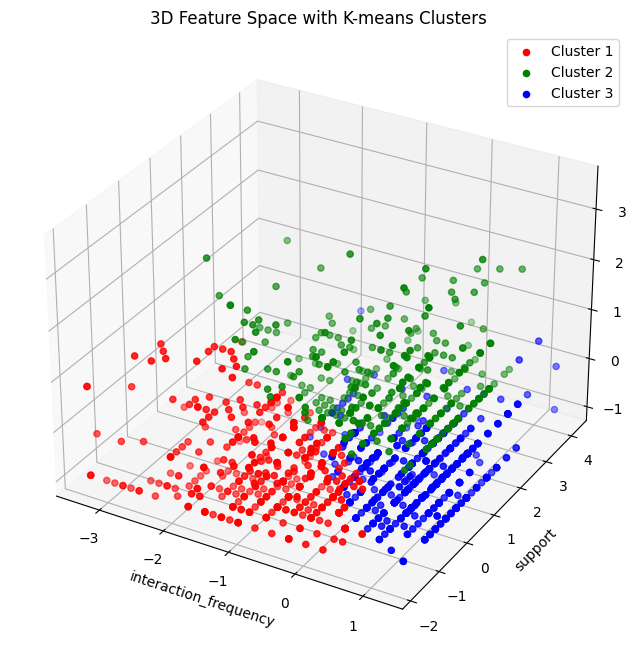

In [70]:
import matplotlib.pyplot as plt

# Plot the features in 3D feature space
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Define the features to plot
x_feature = 'interaction_frequency'
y_feature = 'support'
z_feature = 'conflict'

# Plot each cluster with a different color
colors = ['r', 'g', 'b']
for cluster in range(3):
    X_cluster = X_scaled[X_scaled['cluster'] == cluster]
    ax.scatter(X_cluster[x_feature], X_cluster[y_feature], X_cluster[z_feature], 
               c=colors[cluster], label=f'Cluster {cluster+1}')

# Set labels
ax.set_xlabel(x_feature)
ax.set_ylabel(y_feature)
ax.set_zlabel(z_feature)
ax.set_title('3D Feature Space with K-means Clusters')
ax.legend()

plt.show()

Let's use hierarchical clustering to run the analysis again.

In [71]:
from sklearn.cluster import AgglomerativeClustering

X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Perform K-means clustering
kmeans = AgglomerativeClustering(n_clusters=N_CLUSTERS)
X_scaled['cluster'] = kmeans.fit_predict(X_scaled)
Y['cluster'] = X_scaled['cluster']

In [72]:
# Construct the table
cluster_stats = []

for cluster in range(N_CLUSTERS):
    cluster_data_X = X[X_scaled['cluster'] == cluster]
    cluster_data_Y = Y[Y['cluster'] == cluster]
    
    cluster_stats.append({
        'Cluster': cluster+1,
        **{f"{col}": f"{cluster_data_X[col].mean():.2f}({cluster_data_X[col].std():.2f})" for col in X.columns},
        **{f"{col}": f"{cluster_data_Y[col].mean():.2f}({cluster_data_Y[col].std():.2f})" for col in Y.columns if col != 'cluster'}
    })

cluster_stats_df = pd.DataFrame(cluster_stats)

# Display the table
print(cluster_stats_df.to_string(index=False))

 Cluster interaction_frequency    support   conflict       male   edulevel              income
       1            5.04(0.90) 1.53(0.61) 0.11(0.11) 0.60(0.49) 7.17(1.96) 106640.50(60281.52)
       2            2.98(0.99) 0.62(0.37) 0.07(0.12) 0.64(0.48) 7.03(2.19)  86893.73(52704.75)
       3            4.60(1.14) 1.28(0.59) 0.50(0.14) 0.45(0.50) 7.10(2.01) 103884.98(62896.19)


We found three clusters, too, and while the general pattern was similar, there were some subtle differences in the details.

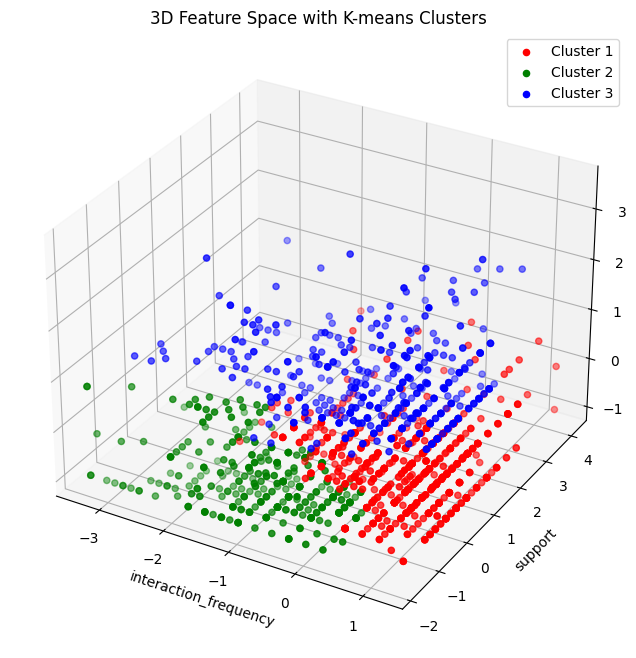

In [73]:
import matplotlib.pyplot as plt

# Plot the features in 3D feature space
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Define the features to plot
x_feature = 'interaction_frequency'
y_feature = 'support'
z_feature = 'conflict'

# Plot each cluster with a different color
colors = ['r', 'g', 'b']
for cluster in range(3):
    X_cluster = X_scaled[X_scaled['cluster'] == cluster]
    ax.scatter(X_cluster[x_feature], X_cluster[y_feature], X_cluster[z_feature], 
               c=colors[cluster], label=f'Cluster {cluster+1}')

# Set labels
ax.set_xlabel(x_feature)
ax.set_ylabel(y_feature)
ax.set_zlabel(z_feature)
ax.set_title('3D Feature Space with K-means Clusters')
ax.legend()

plt.show()